Fitted parameters:
Model 0: K = 119291.2
Model 1: K = 124916.3, d0 = 0.592 cm
Model 2: K = 124693.7, d0 = 0.564 cm
Model 3: K = 124343.1, d0 = 0.521 cm
Model 4: K = 151267.1, d0 = 1.336 cm, f_low = 0.1688


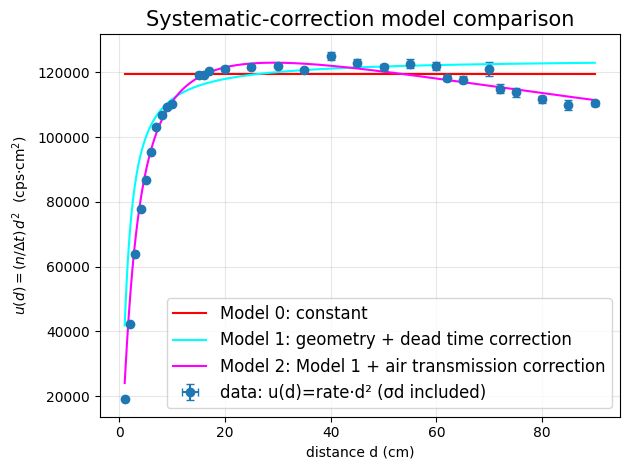

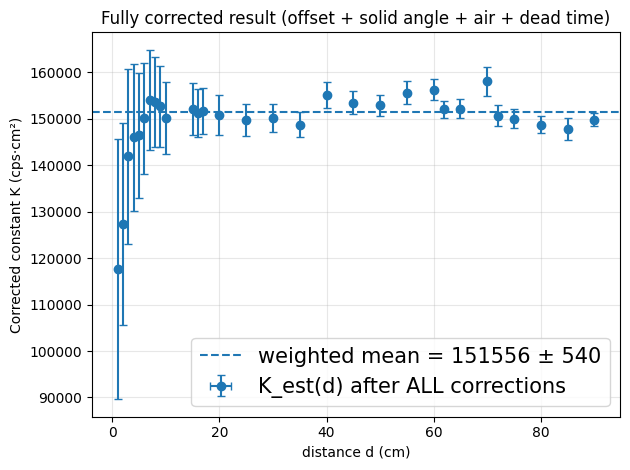

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.odr import ODR, Model, RealData
from scipy.special import lambertw

# =========================
# USER SETTINGS
# =========================
DATA_PATH = "data/filtered_data.csv"   # your file (must have distance_cm and either rate_cps+sigma_rate_cps OR u_cps_cm2+sigma_u_cps_cm2)

# Ruler resolution = 1 cm -> standard uncertainty (uniform rounding ±0.5 cm)
SIGMA_D_CM = 0.5 / np.sqrt(3)

# Dead time (paralyzable)
TAU = 3.12e-6  # seconds

# Detector effective area (cm^2)
A_det_cm2 = 1
a_nom = np.sqrt(A_det_cm2 / np.pi)  # equivalent disk radius in cm

# Air density (room-temp dry air)
rho_air = 0.001204  # g/cm^3

# Sr-90 chain beta endpoints (MeV)
Emax_low, Emax_high = 0.54, 2.27
me = 0.511  # MeV

# =========================
# Helpers
# =========================
def wmean(vals, sig):
    """Weighted mean using 1/sigma^2 weights."""
    w = 1.0 / (sig**2)
    m = np.sum(w * vals) / np.sum(w)
    se = np.sqrt(1.0 / np.sum(w))
    return m, se

def solid_angle_disk(r_cm, a_cm):
    """On-axis solid angle of a circular disk of radius a at distance r."""
    r_cm = np.asarray(r_cm, dtype=float)
    return 2*np.pi*(1 - r_cm / np.sqrt(r_cm**2 + a_cm**2))

def E_from_R(R):
    """
    Invert: R = 0.11*(sqrt(1+22.4 E^2)-1)  ->  E(R)
    R in g/cm^2, E in MeV.
    """
    R = np.asarray(R, dtype=float)
    val = ((1 + R/0.11)**2 - 1) / 22.4
    val = np.maximum(val, 0.0)
    return np.sqrt(val)

def spectrum_allowed(E, E0):
    """Unnormalised allowed beta spectrum (ignore Fermi function), kinetic energy E in MeV."""
    E = np.asarray(E)
    W = E + me
    p = np.sqrt(np.maximum(W**2 - me**2, 0.0))
    return p * W * (E0 - E)**2 * (E >= 0) * (E <= E0)

def build_cdf(E0, N=5000):
    """Build CDF for fast survival fraction lookups."""
    E = np.linspace(0.0, E0, N)
    s = spectrum_allowed(E, E0)
    dE = np.diff(E)
    cum = np.concatenate([[0.0], np.cumsum(0.5*(s[:-1] + s[1:]) * dE)])  # cumulative trapezoid
    cdf = cum / cum[-1] if cum[-1] > 0 else np.zeros_like(cum)
    return E, cdf

# Precompute CDFs for both endpoints (speeds up ODR a lot)
Egrid_low,  CDF_low  = build_cdf(Emax_low,  N=5000)
Egrid_high, CDF_high = build_cdf(Emax_high, N=8000)

def survival_fast(Ecut, Egrid, CDF, E0):
    """Vectorised survival fraction above Ecut using precomputed CDF."""
    Ecut = np.asarray(Ecut, dtype=float)
    Eclip = np.clip(Ecut, 0.0, E0)
    F = np.interp(Eclip, Egrid, CDF)   # fraction below Eclip
    T = 1.0 - F                        # fraction above
    T = np.where(Ecut <= 0.0, 1.0, T)
    T = np.where(Ecut >= E0, 0.0, T)
    return T

def transmission_air(rsep_cm, f_low):
    """Combined beta transmission through air for separation rsep."""
    sigma_air = rho_air * np.asarray(rsep_cm, dtype=float)   # g/cm^2
    Ecut = E_from_R(sigma_air)                               # MeV
    Tlow  = survival_fast(Ecut, Egrid_low,  CDF_low,  Emax_low)
    Thigh = survival_fast(Ecut, Egrid_high, CDF_high, Emax_high)
    return f_low*Tlow + (1-f_low)*Thigh, Tlow, Thigh

def inv_paralyzable(r_obs, tau):
    """Invert r_obs = r*exp(-r*tau) -> r = -W(-tau*r_obs)/tau."""
    r_obs = np.asarray(r_obs, dtype=float)
    if tau == 0:
        return r_obs
    z = -tau * r_obs
    return -lambertw(z).real / tau

def dr_drobs_paralyzable(r_obs, r_true, tau):
    """Derivative dr_true/dr_obs for paralyzable model."""
    if tau == 0:
        return np.ones_like(r_obs, dtype=float)
    denom = (1.0 - r_true * tau)
    denom = np.where(np.abs(denom) < 1e-12, np.nan, denom)
    return np.exp(r_true * tau) / denom

def logistic(p):
    """Map real -> (0,1) for f_low."""
    return 1.0 / (1.0 + np.exp(-p))

# =========================
# Load + collapse repeats
# =========================
df = pd.read_csv(DATA_PATH).copy()
df = df[df["distance_cm"] > 0].copy()

# Two supported input formats:
# (A) columns: distance_cm, rate_cps, sigma_rate_cps
# (B) columns: distance_cm, u_cps_cm2, sigma_u_cps_cm2  (already computed u)

use_u_direct = ("u_cps_cm2" in df.columns) and ("sigma_u_cps_cm2" in df.columns)
use_rate = ("rate_cps" in df.columns) and ("sigma_rate_cps" in df.columns)

if not (use_u_direct or use_rate):
    raise ValueError("CSV must contain either (rate_cps,sigma_rate_cps) or (u_cps_cm2,sigma_u_cps_cm2).")

rows = []
for dist, s in df.groupby("distance_cm"):
    if use_u_direct:
        u_m, su_m = wmean(s["u_cps_cm2"].values, s["sigma_u_cps_cm2"].values)
        rows.append({"distance_cm": dist, "u": u_m, "su": su_m})
    else:
        r_m, sr_m = wmean(s["rate_cps"].values, s["sigma_rate_cps"].values)
        rows.append({"distance_cm": dist, "rate_cps": r_m, "sigma_rate_cps": sr_m})

by = pd.DataFrame(rows).sort_values("distance_cm")
d = by["distance_cm"].to_numpy()
sd = np.full_like(d, SIGMA_D_CM, dtype=float)

# Build u and su consistently
if use_u_direct:
    u = by["u"].to_numpy()
    su = by["su"].to_numpy()
    # We still need r and sr for the final point-by-point corrected K(d) plot:
    # approximate r from u/d^2 (works fine as long as you’re not at d≈0)
    r = u / (d**2)
    sr = su / (d**2)
else:
    r = by["rate_cps"].to_numpy()
    sr = by["sigma_rate_cps"].to_numpy()
    u = r * d**2
    # include sigma_d in u uncertainty
    su = np.sqrt((d**2 * sr)**2 + (2*d*r*sd)**2)

# =========================
# Models for u_obs(d)
# =========================
def f0(beta, x):
    (K,) = beta
    return K*np.ones_like(x)

def f1(beta, x):
    K, d0 = beta
    return K * (x/(x + d0))**2

def f2(beta, x):
    K, d0 = beta
    rsep = x + d0
    Omega = solid_angle_disk(rsep, a_nom)
    return K * (x**2) * Omega / A_det_cm2

def f3(beta, x):
    K, d0 = beta
    rsep = x + d0
    Omega = solid_angle_disk(rsep, a_nom)
    r_det = K * Omega / A_det_cm2
    r_obs = r_det * np.exp(-r_det * TAU)
    return (x**2) * r_obs

# Model 4: offset + solid angle + air transmission + dead time (paralyzable)
# params: [K, d0, p] where f_low = logistic(p)
def f4(beta, x):
    K, d0, p = beta
    f_low = logistic(p)
    rsep = x + d0
    Omega = solid_angle_disk(rsep, a_nom)
    T, _, _ = transmission_air(rsep, f_low)
    r_det = K * Omega / A_det_cm2 * T
    r_obs = r_det * np.exp(-r_det * TAU)
    return (x**2) * r_obs

# =========================
# ODR fits (include σx and σy)
# =========================
data = RealData(d, u, sx=sd, sy=su)

# initial K guess from far-field (d>=20 cm)
mask_far = d >= 20
w_far = 1.0 / su[mask_far]**2
K_guess = np.sum(w_far * u[mask_far]) / np.sum(w_far)




# --- Model 0: fit constant ONLY in far field ---
mask_far = d >= 20  # choose your far-field cutoff

data_far = RealData(d[mask_far], u[mask_far],
                    sx=sd[mask_far], sy=su[mask_far])

# better initial guess: weighted mean in far-field
w_far = 1.0 / su[mask_far]**2
K0_guess = np.sum(w_far * u[mask_far]) / np.sum(w_far)

out0 = ODR(data_far, Model(f0), beta0=[K0_guess]).run()
b0 = out0.beta





out1 = ODR(data, Model(f1), beta0=[K_guess, 0.5]).run()
out2 = ODR(data, Model(f2), beta0=[K_guess, 0.5]).run()
out3 = ODR(data, Model(f3), beta0=[K_guess, 0.5]).run()
out4 = ODR(data, Model(f4), beta0=[K_guess, 0.5, -2.0]).run()  # p=-2 => small-ish f_low start

b0, b1, b2, b3, b4 = out0.beta, out1.beta, out2.beta, out3.beta, out4.beta
K4, d0_4, p4 = b4
f_low_4 = float(logistic(p4))

print("Fitted parameters:")
print(f"Model 0: K = {b0[0]:.1f}")
print(f"Model 1: K = {b1[0]:.1f}, d0 = {b1[1]:.3f} cm")
print(f"Model 2: K = {b2[0]:.1f}, d0 = {b2[1]:.3f} cm")
print(f"Model 3: K = {b3[0]:.1f}, d0 = {b3[1]:.3f} cm")
print(f"Model 4: K = {K4:.1f}, d0 = {d0_4:.3f} cm, f_low = {f_low_4:.4f}")

# =========================
# Plot 1: data + model curves
# =========================
d_grid = np.linspace(d.min(), d.max(), 800)

plt.figure()
plt.errorbar(d, u, xerr=sd, yerr=su, fmt="o", capsize=3,
             label="data: u(d)=rate·d² (σd included)")
plt.plot(d_grid, f0(b0, d_grid), label="Model 0: constant",color='red')
#plt.plot(d_grid, f1(b1, d_grid), label="Model 1: offset only")
#plt.plot(d_grid, f2(b2, d_grid), label="Model 2: offset + solid angle")
plt.plot(d_grid, f3(b3, d_grid), label="Model 1: geometry + dead time correction",color='cyan')
plt.plot(d_grid, f4(b4, d_grid), label="Model 2: Model 1 + air transmission correction",color='magenta')
plt.xlabel("distance d (cm)")
plt.ylabel(r"$u(d)=(n/\Delta t)\,d^2$  (cps·cm$^2$)")
plt.title("Systematic-correction model comparison",fontsize=15)
plt.legend(fontsize=11.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figures/u_vs_d_five_model_comparison.png", dpi=300)
plt.show()

# =========================
# Plot 2: fully corrected constant K_est(d)
#   K_est(d) = r_det * A / (Omega*T)
# where r_det is dead-time corrected (invert paralyzable model)
# =========================
rsep = d + d0_4
Omega = solid_angle_disk(rsep, a_nom)
Tcomb, _, _ = transmission_air(rsep, f_low_4)

r_det = inv_paralyzable(r, TAU)
K_est = r_det * A_det_cm2 / (Omega * Tcomb)

# Uncertainty propagation: sr + sd
drdrobs = dr_drobs_paralyzable(r, r_det, TAU)
s_rdet = np.abs(drdrobs) * sr

# distance sensitivity (finite difference)
def K_from_d_and_r(d_val, r_obs_val):
    rsep_val = d_val + d0_4
    Om = solid_angle_disk(rsep_val, a_nom)
    Tval, _, _ = transmission_air(rsep_val, f_low_4)
    rdet = inv_paralyzable(r_obs_val, TAU)
    return rdet * A_det_cm2 / (Om * Tval)

K_plus  = K_from_d_and_r(d + sd, r)
K_minus = K_from_d_and_r(d - sd, r)
dK_dd = (K_plus - K_minus) / (2*sd)

sK = np.sqrt((A_det_cm2/(Omega*Tcomb) * s_rdet)**2 + (dK_dd * sd)**2)

# Weighted mean line
wK = 1.0 / (sK**2)
K_wmean = np.sum(wK * K_est) / np.sum(wK)
sK_wmean = np.sqrt(1.0 / np.sum(wK))

plt.figure()
plt.errorbar(d, K_est, xerr=sd, yerr=sK, fmt="o", capsize=3,
             label="K_est(d) after ALL corrections")
plt.axhline(K_wmean, linestyle="--",
            label=f"weighted mean = {K_wmean:.0f} ± {sK_wmean:.0f}")
plt.xlabel("distance d (cm)")
plt.ylabel("Corrected constant K (cps·cm²)")
plt.title("Fully corrected result (offset + solid angle + air + dead time)")
plt.legend(fontsize=15)
            # markerscale=1.5, handlelength=2.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figures/K_est_vs_d_all_corrections.png", dpi=600)
plt.show()



=== Model fit comparison (sorted by AIC) ===
                   Model  k        chi2  dof   chi2_red         AIC  \
0  M4 + air transmission  3   20.978564   27   0.776984   26.978564   
1         M3 + dead time  2  200.710643   28   7.168237  204.710643   
2       M2 + solid angle  2  210.937915   28   7.533497  214.937915   
3            M1 + offset  2  214.372274   28   7.656153  218.372274   
4            M0 constant  1  308.736515   29  10.646087  310.736515   

          BIC  
0   31.182156  
1  207.513038  
2  217.740310  
3  221.174668  
4  312.137713  

=== Δchi2 tests (only meaningful when Δk>0) ===
                               Comparison       Δchi2  Δk       p_value
0               M0 constant → M1 + offset   94.364242   1  2.624915e-22
1          M1 + offset → M2 + solid angle    3.434359   0           NaN
2       M2 + solid angle → M3 + dead time   10.227272   0           NaN
3  M3 + dead time → M4 + air transmission  179.732079   1  5.545218e-41

Best model by AIC: M4

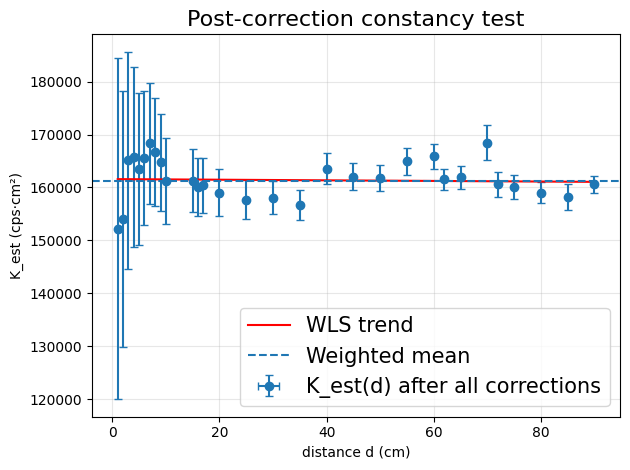

In [2]:
# ============================================================
# Sr-90 u(d)=rate*d^2: Combined systematics + quantitative tests
# - Fits models M0..M4 (offset, solid angle, dead time, air)
# - Runs model-comparison stats (chi2, AIC, BIC, Δchi2 tests)
# - Builds fully-corrected K_est(d) and tests constancy + trend
# Saves:
#   data/model_fit_comparison_stats.csv
#   data/nested_model_delta_chi2_tests.csv
#   data/K_est_all_corrections.csv
#   figures/K_est_constancy_test_plot.png
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.odr import ODR, Model, RealData
from scipy.special import lambertw
from scipy.stats import chi2 as chi2_dist
from scipy.stats import t as t_dist

# =========================
# USER SETTINGS
# =========================
DATA_PATH = "data/filtered_data.csv"   # must have: distance_cm, rate_cps, sigma_rate_cps

# Ruler resolution = 1 cm -> standard uncertainty (uniform rounding ±0.5 cm)
SIGMA_D_CM = 0.5 / np.sqrt(3)

# Dead time (paralyzable)
TAU = 3.12e-6  # seconds

# Detector effective area (cm^2)
A_det_cm2 = 1
a_nom = np.sqrt(A_det_cm2 / np.pi)  # equivalent disk radius in cm

# Air density (room-temp dry air)
rho_air = 0.001204  # g/cm^3

# Sr-90 chain beta endpoints (MeV)
Emax_low, Emax_high = 0.54, 2.27
me = 0.511  # MeV

# Fit region used only for initial K guess (optional)
FAR_MASK_MIN_D_CM = 20

# =========================
# Helpers
# =========================
def wmean(vals, sig):
    w = 1.0 / (sig**2)
    m = np.sum(w * vals) / np.sum(w)
    se = np.sqrt(1.0 / np.sum(w))
    return m, se

def solid_angle_disk(r_cm, a_cm):
    r_cm = np.asarray(r_cm, dtype=float)
    return 2*np.pi*(1 - r_cm / np.sqrt(r_cm**2 + a_cm**2))

# Range-energy relation inversion:
# R = 0.11*(sqrt(1+22.4 E^2)-1)  =>  E(R)=sqrt(((1+R/0.11)^2-1)/22.4)
def E_from_R(R):
    R = np.asarray(R, dtype=float)  # g/cm^2
    val = ((1 + R/0.11)**2 - 1) / 22.4
    val = np.maximum(val, 0.0)
    return np.sqrt(val)  # MeV

def spectrum_allowed(E, E0):
    E = np.asarray(E)
    W = E + me
    p = np.sqrt(np.maximum(W**2 - me**2, 0.0))
    return p * W * (E0 - E)**2 * (E >= 0) * (E <= E0)

def build_cdf(E0, N=5000):
    """Precompute CDF for fast survival fraction 1-CDF(Ecut)."""
    E = np.linspace(0.0, E0, N)
    s = spectrum_allowed(E, E0)
    dE = np.diff(E)
    cum = np.concatenate([[0.0], np.cumsum(0.5*(s[:-1] + s[1:]) * dE)])
    cdf = cum / cum[-1] if cum[-1] > 0 else np.zeros_like(cum)
    return E, cdf

# precompute for low/high endpoints
Egrid_low, CDF_low = build_cdf(Emax_low, N=4000)
Egrid_high, CDF_high = build_cdf(Emax_high, N=7000)

def survival_fast(Ecut, Egrid, CDF, E0):
    """Vectorised survival fraction above Ecut using precomputed CDF."""
    Ecut = np.asarray(Ecut, dtype=float)
    Eclip = np.clip(Ecut, 0.0, E0)
    F = np.interp(Eclip, Egrid, CDF)
    T = 1.0 - F
    T = np.where(Ecut <= 0.0, 1.0, T)
    T = np.where(Ecut >= E0, 0.0, T)
    return T

def logistic(p):
    return 1.0/(1.0 + np.exp(-p))

def transmission_air(rsep_cm, f_low):
    """Combined beta transmission through air, using range-energy cutoff."""
    sigma_air = rho_air * np.asarray(rsep_cm, dtype=float)  # g/cm^2
    Ecut = E_from_R(sigma_air)
    Tlow = survival_fast(Ecut, Egrid_low, CDF_low, Emax_low)
    Thigh = survival_fast(Ecut, Egrid_high, CDF_high, Emax_high)
    return f_low*Tlow + (1-f_low)*Thigh, Tlow, Thigh

# Paralyzable dead time: r_obs = r_true * exp(-r_true*tau)
# Invert: r_true = -W(-tau*r_obs)/tau
def inv_paralyzable(r_obs, tau):
    r_obs = np.asarray(r_obs, dtype=float)
    if tau == 0:
        return r_obs
    z = -tau * r_obs
    return -lambertw(z).real / tau

def dr_drobs_paralyzable(r_obs, r_true, tau):
    """Derivative dr_true/dr_obs for uncertainty propagation."""
    if tau == 0:
        return np.ones_like(r_obs, dtype=float)
    denom = (1.0 - r_true * tau)
    denom = np.where(np.abs(denom) < 1e-12, np.nan, denom)
    return np.exp(r_true * tau) / denom

# =========================
# Load + collapse repeats
# =========================
df = pd.read_csv(DATA_PATH).copy()
df = df[df["distance_cm"] > 0].copy()

rows = []
for dist, s in df.groupby("distance_cm"):
    r_m, sr_m = wmean(s["rate_cps"].values, s["sigma_rate_cps"].values)
    rows.append({"distance_cm": dist, "rate_cps": r_m, "sigma_rate_cps": sr_m})

by = pd.DataFrame(rows).sort_values("distance_cm")
d  = by["distance_cm"].to_numpy()
r  = by["rate_cps"].to_numpy()
sr = by["sigma_rate_cps"].to_numpy()

N = len(d)
sd = np.full_like(d, SIGMA_D_CM, dtype=float)

# Construct u(d)=r_obs*d^2 and propagate sigma_d into sigma_u
u  = r * d**2
su = np.sqrt((d**2 * sr)**2 + (2*d*r*sd)**2)

# =========================
# Models for u_obs(d)
# =========================
def f0(beta, x):
    (K,) = beta
    return K*np.ones_like(x)

def f1(beta, x):
    K, d0 = beta
    return K * (x/(x + d0))**2

def f2(beta, x):
    K, d0 = beta
    rsep = x + d0
    Omega = solid_angle_disk(rsep, a_nom)
    return K * (x**2) * Omega / A_det_cm2

def f3(beta, x):
    K, d0 = beta
    rsep = x + d0
    Omega = solid_angle_disk(rsep, a_nom)
    r_det = K * Omega / A_det_cm2
    r_obs = r_det * np.exp(-r_det * TAU)
    return (x**2) * r_obs

# M4: offset + solid angle + dead time + air transmission
# params: [K, d0, p], with f_low=logistic(p)
def f4(beta, x):
    K, d0, p = beta
    f_low = logistic(p)
    rsep = x + d0
    Omega = solid_angle_disk(rsep, a_nom)
    T, _, _ = transmission_air(rsep, f_low)
    r_det = K * Omega / A_det_cm2 * T
    r_obs = r_det * np.exp(-r_det * TAU)
    return (x**2) * r_obs

models = [
    ("M0 constant", f0, 1, None),
    ("M1 + offset", f1, 2, None),
    ("M2 + solid angle", f2, 2, None),
    ("M3 + dead time", f3, 2, None),
    ("M4 + air transmission", f4, 3, None),
]

# =========================
# Fit with ODR (σx and σy)
# =========================
data = RealData(d, u, sx=sd, sy=su)

mask_far = d >= FAR_MASK_MIN_D_CM
w_far = 1.0 / su[mask_far]**2
K_guess = np.sum(w_far * u[mask_far]) / np.sum(w_far)

# set starting guesses
beta0_map = {
    "M0 constant": [K_guess],
    "M1 + offset": [K_guess, 0.5],
    "M2 + solid angle": [K_guess, 0.5],
    "M3 + dead time": [K_guess, 0.5],
    "M4 + air transmission": [K_guess, 0.5, -4.0],
}

odr_out = {}
fit_rows = []

for name, f, k, _ in models:
    out = ODR(data, Model(f), beta0=beta0_map[name]).run()
    odr_out[name] = out

    beta = out.beta
    yhat = f(beta, d)

    # Reportable chi-square vs sigma_u
    chi2 = np.sum(((u - yhat)/su)**2)
    dof = N - k
    chi2_red = chi2 / dof

    # AIC/BIC (Gaussian with known sigmas -> constants drop out)
    AIC = chi2 + 2*k
    BIC = chi2 + k*np.log(N)

    fit_rows.append({
        "Model": name,
        "k": k,
        "chi2": chi2,
        "dof": dof,
        "chi2_red": chi2_red,
        "AIC": AIC,
        "BIC": BIC,
        "params": beta,
        "param_unc": out.sd_beta
    })

fit_df = pd.DataFrame(fit_rows).sort_values("AIC").reset_index(drop=True)

print("\n=== Model fit comparison (sorted by AIC) ===")
print(fit_df[["Model","k","chi2","dof","chi2_red","AIC","BIC"]])

# =========================
# Nested Δchi2 tests (where Δk>0)
# =========================
order = ["M0 constant","M1 + offset","M2 + solid angle","M3 + dead time","M4 + air transmission"]
name_to = {row["Model"]: row for row in fit_rows}

tests = []
for a,b in zip(order[:-1], order[1:]):
    ra, rb = name_to[a], name_to[b]
    dchi = ra["chi2"] - rb["chi2"]
    dk = rb["k"] - ra["k"]
    p = chi2_dist.sf(dchi, dk) if (dk > 0 and dchi >= 0) else np.nan
    tests.append({"Comparison": f"{a} → {b}", "Δchi2": dchi, "Δk": dk, "p_value": p})

test_df = pd.DataFrame(tests)
print("\n=== Δchi2 tests (only meaningful when Δk>0) ===")
print(test_df)

# =========================
# Post-correction: build K_est(d) from best model (AIC)
# =========================
best_model = fit_df.loc[0, "Model"]
print(f"\nBest model by AIC: {best_model}")

if best_model != "M4 + air transmission":
    print("Note: This script assumes M4 is best for the post-correction part.")
    best_model = "M4 + air transmission"

b4 = odr_out[best_model].beta
K4, d0_4, p4 = b4
f_low_4 = float(logistic(p4))

# Correct each point:
# 1) invert dead time to get r_det
# 2) divide out solid angle and air transmission to estimate K
rsep = d + d0_4
Omega = solid_angle_disk(rsep, a_nom)
Tcomb, _, _ = transmission_air(rsep, f_low_4)

r_det = inv_paralyzable(r, TAU)
K_est = r_det * A_det_cm2 / (Omega * Tcomb)

# Uncertainty propagation (sr + sd via finite difference)
drdrobs = dr_drobs_paralyzable(r, r_det, TAU)
s_rdet = np.abs(drdrobs) * sr

def K_from_d_and_r(d_val, r_obs_val):
    rsep_val = d_val + d0_4
    Om = solid_angle_disk(rsep_val, a_nom)
    Tval, _, _ = transmission_air(rsep_val, f_low_4)
    rdet = inv_paralyzable(r_obs_val, TAU)
    return rdet * A_det_cm2 / (Om * Tval)

K_plus  = K_from_d_and_r(d + sd, r)
K_minus = K_from_d_and_r(d - sd, r)
dK_dd = (K_plus - K_minus) / (2*sd)

sK = np.sqrt((A_det_cm2/(Omega*Tcomb) * s_rdet)**2 + (dK_dd * sd)**2)

# =========================
# Statistical tests on K_est(d)
# =========================
# 1) Constancy: chi-square about weighted mean
wK = 1.0/(sK**2)
K_bar = np.sum(wK*K_est)/np.sum(wK)
sK_bar = np.sqrt(1.0/np.sum(wK))

chi2_K = np.sum(((K_est - K_bar)/sK)**2)
dof_K = N - 1
p_constancy = chi2_dist.sf(chi2_K, dof_K)

# 2) Trend: weighted linear regression (K = m d + c)
W = np.diag(wK)
X = np.vstack([d, np.ones_like(d)]).T
XTWX = X.T @ W @ X
XTWy = X.T @ W @ K_est
m, c = np.linalg.solve(XTWX, XTWy)
cov = np.linalg.inv(XTWX)
sm = np.sqrt(cov[0,0])
t_stat = m/sm
p_slope = 2*t_dist.sf(np.abs(t_stat), N-2)

print("\n=== Best-fit M4 parameters ===")
print(f"K = {K4:.1f} cps·cm^2, d0 = {d0_4:.3f} cm, f_low = {f_low_4:.4f}")
print("\n=== Post-correction constancy tests ===")
print(f"Weighted mean K̄ = {K_bar:.0f} ± {sK_bar:.0f} cps·cm^2")
print(f"Constancy chi2 = {chi2_K:.2f} for dof={dof_K}  -> p = {p_constancy:.3f}")
print(f"Slope m = {m:.2f} ± {sm:.2f} (cps·cm^2)/cm  -> p = {p_slope:.3f}")

# =========================
# Save outputs for report
# =========================
fit_df[["Model","k","chi2","dof","chi2_red","AIC","BIC"]].to_csv(
    "data/model_fit_comparison_stats.csv", index=False
)
test_df.to_csv("data/nested_model_delta_chi2_tests.csv", index=False)
pd.DataFrame({"distance_cm": d, "K_est": K_est, "sigma_K": sK}).to_csv(
    "data/K_est_all_corrections.csv", index=False
)

# Plot for report: K_est(d) with trend and mean
d_grid = np.linspace(d.min(), d.max(), 300)
K_line = m*d_grid + c

plt.figure()
plt.errorbar(d, K_est, xerr=sd, yerr=sK, fmt="o", capsize=3, label="K_est(d) after all corrections")
plt.plot(d_grid, K_line, label=f"WLS trend",color='red')
plt.axhline(K_bar, linestyle="--", label=f"Weighted mean")
plt.xlabel("distance d (cm)")
plt.ylabel("K_est (cps·cm²)")
plt.title("Post-correction constancy test",fontsize=16)
plt.legend(fontsize=15)
plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig("figures/K_est_constancy_test_plot.png", dpi=300)
plt.show()


In [3]:
from scipy.stats import chi2

def chi2_gof(out, N, m):
    chi2_obs = out.sum_square
    dof = N - m
    chi2_red = chi2_obs / dof
    p = chi2.sf(chi2_obs, dof)   # upper-tail probability
    return chi2_obs, dof, chi2_red, p

# Example usage:
# Model 0 uses far-field points only:
N0 = mask_far.sum()
m0 = 1
print("Model 0:", chi2_gof(out0, N0, m0))

# Models 1–4 use all points:
N = len(d)
print("Model 1:", chi2_gof(out1, N, 2))
print("Model 2:", chi2_gof(out2, N, 2))
print("Model 3:", chi2_gof(out3, N, 2))
print("Model 4:", chi2_gof(out4, N, 3))

# Note: out.res_var is approximately chi2_red too:
print("Model 4 res_var (≈ chi2_red):", out4.res_var)


Model 0: (357.8580238405362, np.int64(16), np.float64(22.366126490033512), np.float64(2.375102000703316e-66))
Model 1: (1065.6844572057043, 28, 38.06015918591801, np.float64(1.7855360192301563e-206))
Model 2: (1035.8056796198287, 28, 36.99305998642245, np.float64(3.7985724605329697e-200))
Model 3: (990.1455780955248, 28, 35.36234207484017, np.float64(1.740080113444625e-190))
Model 4: (67.92250698635443, 27, 2.515648406902016, np.float64(2.2081617319951126e-05))
Model 4 res_var (≈ chi2_red): 2.515648406902016
